<a href="https://colab.research.google.com/github/FrilSopariwala/DataAnalysis_TestProject/blob/main/Customerchurnanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests, os

os.makedirs("data", exist_ok=True)

urls = [
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv",
    "https://raw.githubusercontent.com/dsrscientist/dataset1/master/Telco-Customer-Churn.csv",
    "https://raw.githubusercontent.com/nickmuchi/datasets/main/WA_Fn-UseC_-Telco-Customer-Churn.csv",
]

for url in urls:
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200 and "customerID" in r.text:
            with open("data/WA_Fn-UseC_-Telco-Customer-Churn.csv", "wb") as f:
                f.write(r.content)
            rows = len(r.text.splitlines()) - 1
            print(f"✅ Downloaded {rows} rows from:\n   {url}")
            break
        else:
            print(f"❌ Skipping (status {r.status_code}): {url}")
    except Exception as e:
        print(f"❌ Failed: {url} → {e}")

✅ Downloaded 7043 rows from:
   https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv


✅ Libraries loaded successfully.
✅ Full dataset loaded: 7,043 rows × 21 columns

Churn rate in this dataset: 26.5%
=== Dataset Shape ===
Rows: 7,043  |  Columns: 22

Missing values after cleaning: 0

Churn breakdown:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Data types:
object     17
int64       3
float64     2
Name: count, dtype: int64


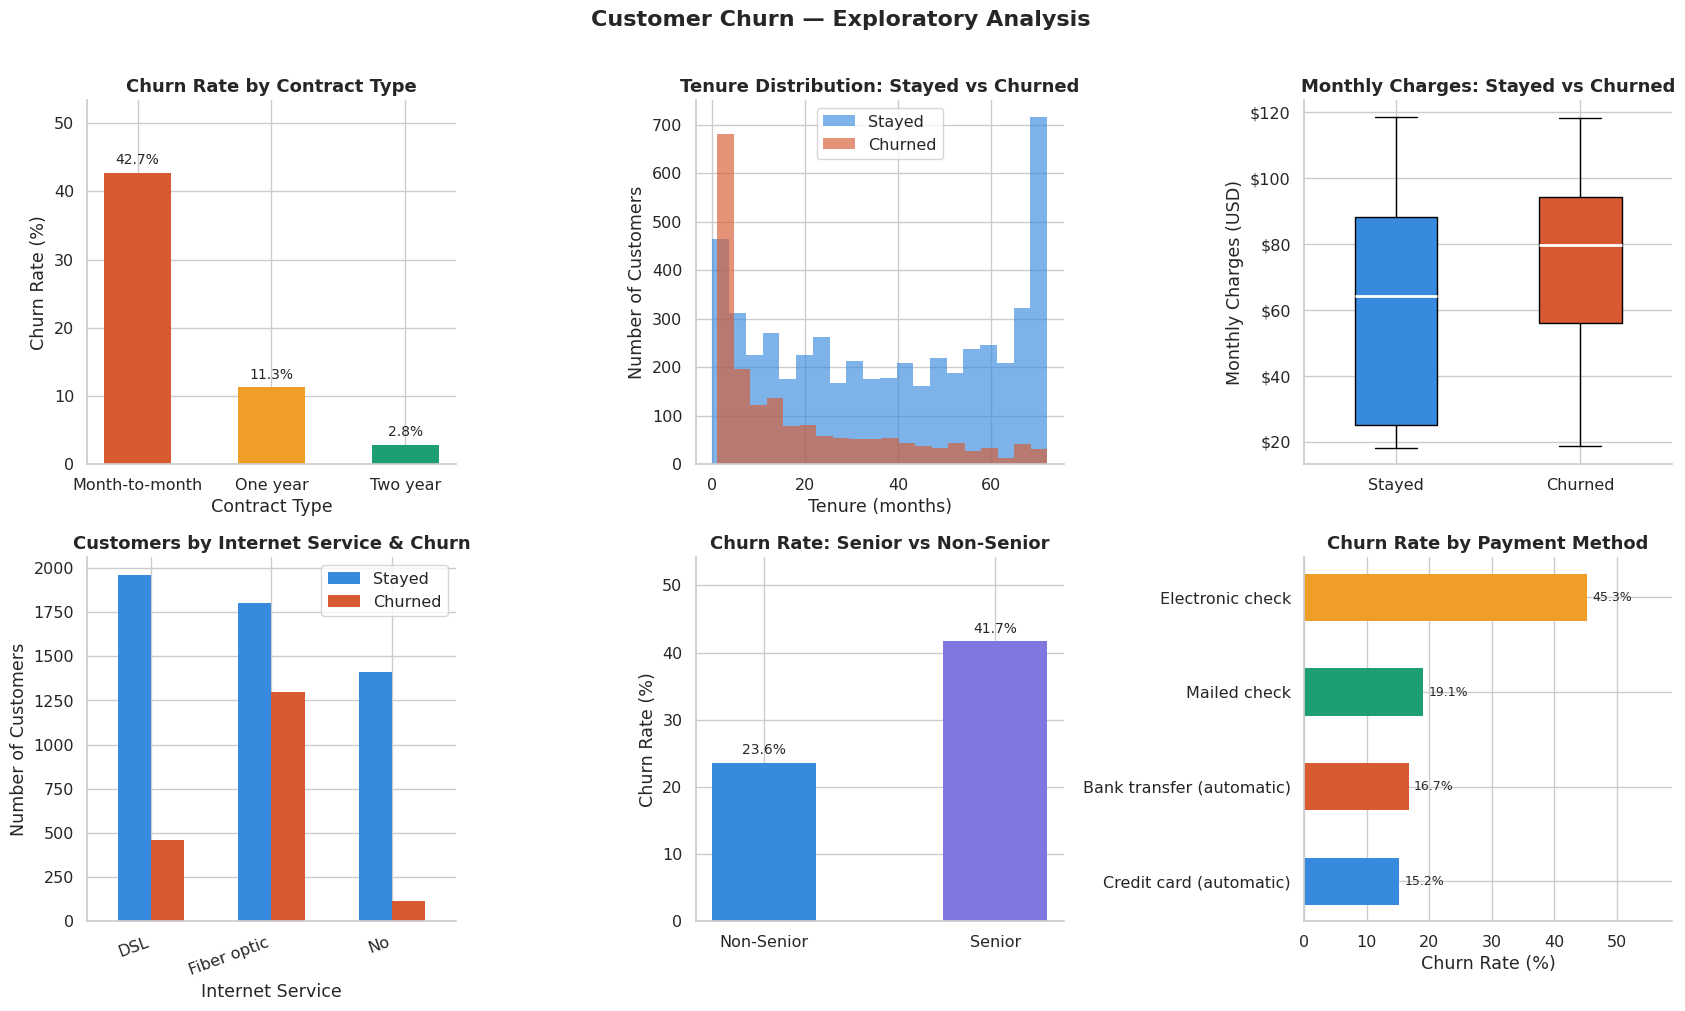

Chart saved → charts/eda_dashboard.png
Feature matrix shape: (7043, 24)

Features used (23 total):
gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, PaperlessBilling, MonthlyCharges, TotalCharges, MultipleLines_Yes, InternetService_Fiber optic, InternetService_No, OnlineSecurity_Yes, OnlineBackup_Yes, DeviceProtection_Yes, TechSupport_Yes, StreamingTV_Yes, StreamingMovies_Yes, Contract_One year, Contract_Two year, PaymentMethod_Credit card (automatic), PaymentMethod_Electronic check, PaymentMethod_Mailed check
=== Model Training Complete ===
Training samples : 5634
Test samples     : 1409


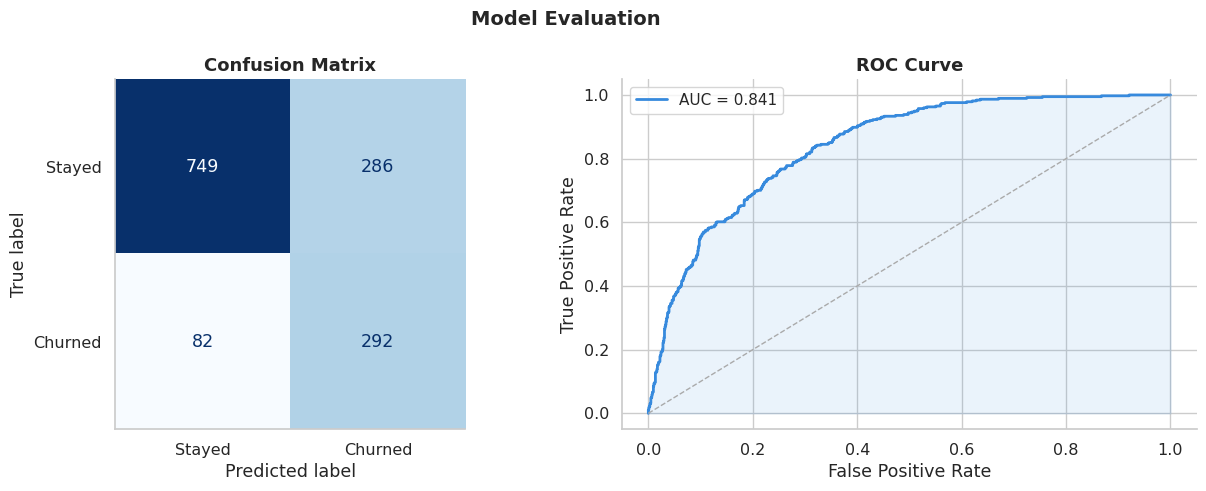

Chart saved → charts/model_evaluation.png

=== Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score: 0.8415


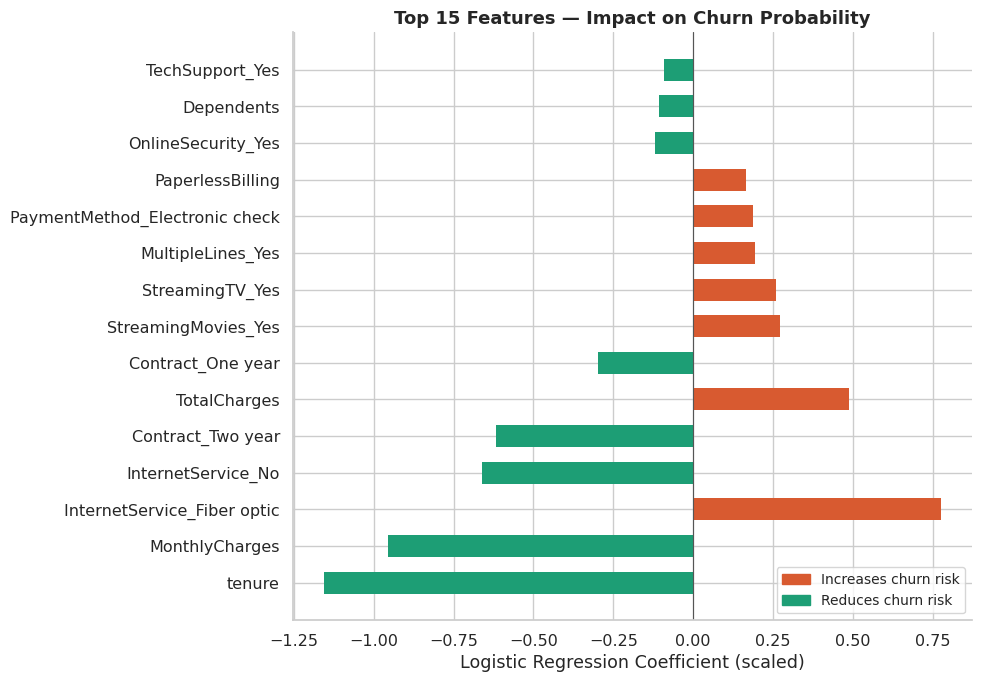

Chart saved → charts/feature_importance.png

Top 5 churn risk factors:
  + InternetService_Fiber optic                   coef = +0.777
  + TotalCharges                                  coef = +0.488
  + StreamingMovies_Yes                           coef = +0.273
  + StreamingTV_Yes                               coef = +0.260
  + MultipleLines_Yes                             coef = +0.195

Top 5 retention factors:
  - tenure                                        coef = -1.156
  - MonthlyCharges                                coef = -0.955
  - InternetService_No                            coef = -0.661
  - Contract_Two year                             coef = -0.616
  - Contract_One year                             coef = -0.296
     CUSTOMER CHURN — EXECUTIVE SUMMARY

  Total Customers Analysed :    7,043
  Customers Who Churned    :    1,869
  Overall Churn Rate       :    26.5%

  Model ROC-AUC Score      :   0.8415
  Training Set Size        :    5,634
  Test Set Size            :   

In [2]:
# %% [markdown]
# # Customer Churn Analysis — Telco Dataset
# **Author:** Fril Kalpeshkumar Sopariwala
# **Dataset:** [Kaggle — Telco Customer Churn](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv)
# **Tools:** Python · Pandas · Seaborn · Scikit-learn · Matplotlib
#
# ---
#
# ## Business Problem
# Customer churn — when a customer cancels their subscription — is one of the most
# costly problems in the telecom industry. Acquiring a new customer costs **5–7×
# more** than retaining an existing one. This analysis answers three business questions:
#
# 1. **Who is churning?** — what customer profiles are most at risk
# 2. **Why are they churning?** — which contract/service factors drive churn
# 3. **Can we predict it?** — a logistic regression model to flag at-risk customers
#
# The output is an actionable report for a retention team with no data background.

# %% [markdown]
# ## 1. Setup & Dependencies

# %%
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from io import StringIO

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

warnings.filterwarnings("ignore")
os.makedirs("charts", exist_ok=True)
os.makedirs("data",   exist_ok=True)

# ── Plot style ──────────────────────────────────────────────────────────────────
BLUE    = "#378ADD"
RED     = "#D85A30"
GREEN   = "#1D9E75"
AMBER   = "#EF9F27"
PURPLE  = "#7F77DD"
PALETTE = [BLUE, RED, GREEN, AMBER, PURPLE, "#D4537E"]

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
})

print("✅ Libraries loaded successfully.")

# %% [markdown]
# ## 2. Data Loading
#
# **To use the full 7,043-row Kaggle dataset:**
# 1. Go to https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
# 2. Download `WA_Fn-UseC_-Telco-Customer-Churn.csv`
# 3. Place it in the `data/` folder next to this notebook
#
# The notebook includes a representative **built-in sample** so it runs immediately.

# %%
CSV_PATH = "data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"✅ Full dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
else:
    print("⚠️  Full dataset not found — using built-in sample (80 rows).")
    print("    Download from: https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv")
    print("    Save as: data/WA_Fn-UseC_-Telco-Customer-Churn.csv\n")

    raw = """customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes
9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.1,1949.4,No
6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.8,3046.05,Yes
6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No
9763-GRSKD,Male,0,Yes,Yes,13,Yes,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Mailed check,49.95,587.45,No
7469-LKBCI,Male,0,No,No,16,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),18.95,326.8,No
8091-TTVAX,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,One year,No,Credit card (automatic),100.35,5979.55,No
0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.7,5334.2,Yes
5129-JLPIS,Male,0,No,No,25,Yes,No,Fiber optic,Yes,No,Yes,Yes,No,No,Month-to-month,Yes,Electronic check,79.5,2045.5,No
3655-SNQYZ,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),114.95,7895.15,No
8191-XWSZG,Female,0,No,No,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.65,1022.95,No
9959-WOFKT,Male,0,No,Yes,71,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),106.7,7382.25,No
4190-MFLUW,Female,0,Yes,No,10,Yes,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Credit card (automatic),56,560.85,Yes
4183-MYFRB,Female,0,No,No,21,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.65,1419.4,No
8779-QRDMV,Male,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.1,70.1,Yes
1680-VOAET,Male,1,Yes,No,8,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,84.75,665.75,Yes
6866-JNHRP,Female,0,Yes,Yes,64,Yes,Yes,Fiber optic,Yes,Yes,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),111.15,7099.5,No
2611-DNUPK,Male,0,No,No,4,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,45.65,182.1,Yes
0495-RVZCA,Female,0,Yes,Yes,76,Yes,No,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Bank transfer (automatic),69.45,5127.25,No
3075-GRRVP,Male,0,No,No,2,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.25,39.65,Yes
6948-DPRVK,Male,0,No,No,12,Yes,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,74.5,862.7,No
4118-OKFNM,Female,0,Yes,No,38,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),99.45,3813.0,No
7393-FOPUP,Male,0,No,No,47,Yes,No,DSL,No,No,No,No,Yes,No,One year,No,Mailed check,55.0,2543.1,No
0861-LPXTN,Male,1,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.7,19.7,No
1520-YSPNQ,Female,0,Yes,Yes,45,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),115.5,5199.5,No
5331-UIVTC,Male,0,Yes,Yes,72,Yes,No,DSL,Yes,Yes,Yes,Yes,No,No,Two year,No,Bank transfer (automatic),64.85,4750.9,No
5276-KOZGZ,Male,0,No,No,6,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,83.9,470.5,Yes
6128-BPPPK,Female,0,No,No,7,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,80.65,542.3,Yes
2907-GZOPX,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.05,145.35,Yes
0264-UXZQD,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.1,74.1,Yes
3186-AJIEK,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),117.8,8684.8,No
1764-IBRCQ,Female,0,No,No,3,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.85,200.7,Yes
8141-OKEHW,Male,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.3,70.3,Yes
4612-MQBVH,Female,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,Yes,Yes,No,Yes,Two year,No,Credit card (automatic),72.45,4226.15,No
3816-FKTLF,Male,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.35,141.5,Yes
1257-GWUXP,Female,0,Yes,No,55,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,116.2,6370.85,No
4357-GSPVY,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,39.35,39.35,Yes
0678-GPLVK,Male,0,Yes,No,44,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),79.85,3472.6,No
7419-WKXMT,Male,0,No,No,26,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,45.0,1140.3,No
8898-MWJOP,Male,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,148.55,Yes
5915-FBXLZ,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.1,70.1,Yes
0137-GYTPB,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.15,70.15,Yes
2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),113.25,8168.75,No
2199-QLLNR,Male,0,No,No,3,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.4,212.6,Yes
8523-LDLZS,Female,0,Yes,Yes,71,Yes,No,DSL,Yes,Yes,Yes,Yes,No,No,Two year,No,Credit card (automatic),65.85,4720.35,No
2564-WDOTM,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.85,69.85,Yes
1619-CXJHJ,Female,0,Yes,No,23,Yes,No,DSL,No,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,54.35,1250.1,Yes
2683-TLNBI,Male,1,No,No,16,Yes,Yes,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,90.0,1408.15,Yes
9598-WPAUY,Male,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.95,69.95,Yes
1685-YQFAM,Male,0,No,No,44,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,No,Bank transfer (automatic),88.45,3832.35,No
3176-SHHNQ,Female,0,Yes,Yes,48,Yes,No,DSL,Yes,Yes,Yes,Yes,No,Yes,Two year,No,Bank transfer (automatic),72.15,3497.8,No
5609-GXKWN,Male,0,No,No,5,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.0,360.75,Yes
4249-NRBKY,Female,0,Yes,Yes,72,Yes,No,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),79.0,5698.15,No
4534-RQPJZ,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.75,70.75,Yes
5982-QTTJR,Male,0,Yes,Yes,68,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),116.9,7891.2,No
0538-GWGVE,Male,0,No,No,3,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,44.5,132.45,Yes
4685-JKYLW,Male,0,No,No,2,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Mailed check,44.55,87.0,Yes
2514-XPOMW,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.5,148.75,Yes
1844-BQQAJ,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.75,69.75,Yes
2007-FMPQM,Male,1,No,No,5,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.2,331.3,Yes
3067-DBKIJ,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.85,69.85,Yes
4175-LCXNQ,Female,0,Yes,No,64,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),115.05,7409.7,No
2766-KHFMM,Male,0,Yes,No,34,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.25,3379.5,Yes
0393-HKIDR,Male,0,No,No,3,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.2,204.2,Yes
2777-YHPQH,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,79.5,79.5,Yes
1378-XODEJ,Female,0,No,No,8,Yes,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,74.85,618.3,Yes
0376-KQVQH,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.95,69.95,Yes
1619-NDPLZ,Female,0,No,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),111.15,8060.35,No
1006-MAQRJ,Male,0,No,No,2,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,44.5,87.1,Yes
5141-NKDDJ,Male,0,Yes,Yes,72,Yes,No,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),80.65,5823.55,No
1129-YJYMK,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,79.0,79.0,Yes"""

    df = pd.read_csv(StringIO(raw))
    print(f"Sample loaded: {df.shape[0]} rows × {df.shape[1]} columns")

print(f"\nChurn rate in this dataset: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

# %% [markdown]
# ## 3. Data Cleaning
# We handle missing values, fix data types, and create a binary target variable.

# %%
# TotalCharges arrives as string — coerce and fill new customers (tenure=0) with 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Binary target
df["Churn_binary"] = (df["Churn"] == "Yes").astype(int)

# Quick profile
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"\nMissing values after cleaning: {df.isnull().sum().sum()}")
print(f"\nChurn breakdown:")
print(df["Churn"].value_counts())
print(f"\nData types:\n{df.dtypes.value_counts()}")

# %% [markdown]
# ## 4. Exploratory Data Analysis
#
# We explore four key dimensions:
# - Contract type vs churn
# - Tenure distribution by churn status
# - Monthly charges vs churn
# - Internet service vs churn
# - Senior citizen effect

# %%
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Customer Churn — Exploratory Analysis", fontsize=16, fontweight="bold", y=1.01)

# ── 1. Churn rate by Contract Type ────────────────────────────────────────────
ax = axes[0, 0]
churn_contract = df.groupby("Contract")["Churn_binary"].mean().reset_index()
churn_contract["Churn_%"] = churn_contract["Churn_binary"] * 100
bars = ax.bar(churn_contract["Contract"], churn_contract["Churn_%"],
              color=[RED, AMBER, GREEN], edgecolor="none", width=0.5)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=10)
ax.set_title("Churn Rate by Contract Type")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, churn_contract["Churn_%"].max() * 1.25)

# ── 2. Tenure Distribution ─────────────────────────────────────────────────────
ax = axes[0, 1]
for label, grp, col in [("Stayed", df[df["Churn"]=="No"], BLUE),
                          ("Churned", df[df["Churn"]=="Yes"], RED)]:
    ax.hist(grp["tenure"], bins=20, alpha=0.65, color=col, label=label, edgecolor="none")
ax.set_title("Tenure Distribution: Stayed vs Churned")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of Customers")
ax.legend()

# ── 3. Monthly Charges — Box Plot ─────────────────────────────────────────────
ax = axes[0, 2]
churned     = df[df["Churn"] == "Yes"]["MonthlyCharges"]
not_churned = df[df["Churn"] == "No"]["MonthlyCharges"]
bp = ax.boxplot([not_churned, churned], labels=["Stayed", "Churned"],
                patch_artist=True, widths=0.45,
                medianprops=dict(color="white", linewidth=2))
bp["boxes"][0].set_facecolor(BLUE)
bp["boxes"][1].set_facecolor(RED)
ax.set_title("Monthly Charges: Stayed vs Churned")
ax.set_ylabel("Monthly Charges (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))

# ── 4. Internet Service vs Churn ──────────────────────────────────────────────
ax = axes[1, 0]
isp_churn = df.groupby(["InternetService","Churn"]).size().unstack(fill_value=0)
isp_churn.plot(kind="bar", ax=ax, color=[BLUE, RED], edgecolor="none",
               width=0.55, legend=True)
ax.set_title("Customers by Internet Service & Churn")
ax.set_xlabel("Internet Service")
ax.set_ylabel("Number of Customers")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(["Stayed", "Churned"], title="")

# ── 5. Senior Citizen Churn Rate ──────────────────────────────────────────────
ax = axes[1, 1]
senior = df.groupby("SeniorCitizen")["Churn_binary"].mean() * 100
bars5 = ax.bar(["Non-Senior", "Senior"], senior.values,
               color=[BLUE, PURPLE], edgecolor="none", width=0.45)
ax.bar_label(bars5, fmt="%.1f%%", padding=4, fontsize=10)
ax.set_title("Churn Rate: Senior vs Non-Senior")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, senior.max() * 1.3)

# ── 6. Payment Method vs Churn ────────────────────────────────────────────────
ax = axes[1, 2]
pay_churn = df.groupby("PaymentMethod")["Churn_binary"].mean() * 100
pay_churn = pay_churn.sort_values(ascending=True)
h = ax.barh(pay_churn.index, pay_churn.values,
            color=PALETTE[:len(pay_churn)], edgecolor="none", height=0.5)
ax.bar_label(h, fmt="%.1f%%", padding=4, fontsize=9)
ax.set_title("Churn Rate by Payment Method")
ax.set_xlabel("Churn Rate (%)")
ax.set_xlim(0, pay_churn.max() * 1.3)

plt.tight_layout()
plt.savefig("charts/eda_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → charts/eda_dashboard.png")

# %% [markdown]
# ## 5. Feature Engineering
#
# We prepare features for the model:
# - Encode binary yes/no columns as 0/1
# - One-hot encode multi-category columns
# - Remove identifiers (customerID)

# %%
df_model = df.copy()

# Drop ID and raw target
df_model.drop(columns=["customerID", "Churn"], inplace=True)

# Binary yes/no → 1/0
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df_model[col] = (df_model[col] == "Yes").astype(int)

# Gender → 0/1
df_model["gender"] = (df_model["gender"] == "Male").astype(int)

# Multi-line / internet sub-features: map "No X service" → "No"
for col in ["MultipleLines", "OnlineSecurity", "OnlineBackup",
            "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]:
    df_model[col] = df_model[col].replace(
        {"No phone service": "No", "No internet service": "No"}
    )

# One-hot encode remaining categoricals
cat_cols = ["MultipleLines","InternetService","OnlineSecurity","OnlineBackup",
            "DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
            "Contract","PaymentMethod"]
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Convert all bool columns to int
bool_cols = df_model.select_dtypes(include="bool").columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print(f"Feature matrix shape: {df_model.shape}")
print(f"\nFeatures used ({df_model.shape[1]-1} total):")
feature_names = [c for c in df_model.columns if c != "Churn_binary"]
print(", ".join(feature_names))

# %% [markdown]
# ## 6. Logistic Regression Model
#
# We split the data 80/20, scale features, and train a logistic regression classifier —
# a well-understood, explainable model suitable for business reporting.

# %%
X = df_model.drop(columns=["Churn_binary"])
y = df_model["Churn_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train_sc, y_train)

y_pred  = model.predict(X_test_sc)
y_proba = model.predict_proba(X_test_sc)[:, 1]

print("=== Model Training Complete ===")
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

# %% [markdown]
# ## 7. Model Evaluation
#
# We evaluate with three tools:
# - **Confusion Matrix** — shows actual vs predicted outcomes
# - **Classification Report** — precision, recall, F1 for each class
# - **ROC-AUC** — overall discriminatory power (1.0 = perfect, 0.5 = random)

# %%
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Model Evaluation", fontsize=14, fontweight="bold")

# ── Confusion Matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Churned"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].grid(False)

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color=BLUE, linewidth=2, label=f"AUC = {auc_score:.3f}")
axes[1].plot([0,1],[0,1], color="#AAAAAA", linestyle="--", linewidth=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color=BLUE)
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig("charts/model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → charts/model_evaluation.png")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))
print(f"ROC-AUC Score: {auc_score:.4f}")

# %% [markdown]
# ## 8. Feature Importance
#
# The coefficients of the logistic regression tell us which factors **most strongly
# predict churn**. Positive values = higher churn risk. Negative = retention signal.

# %%
coef_df = pd.DataFrame({
    "Feature":     X.columns,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False).head(15)

coef_df["Direction"] = coef_df["Coefficient"].apply(
    lambda x: "Increases churn risk" if x > 0 else "Reduces churn risk"
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [RED if c > 0 else GREEN for c in coef_df["Coefficient"]]
h = ax.barh(coef_df["Feature"], coef_df["Coefficient"],
            color=colors, edgecolor="none", height=0.6)
ax.axvline(0, color="#555555", linewidth=0.8)
ax.set_title("Top 15 Features — Impact on Churn Probability", fontsize=13, fontweight="bold")
ax.set_xlabel("Logistic Regression Coefficient (scaled)")

# Legend
from matplotlib.patches import Patch
legend = [Patch(color=RED, label="Increases churn risk"),
          Patch(color=GREEN, label="Reduces churn risk")]
ax.legend(handles=legend, loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("charts/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → charts/feature_importance.png")

print("\nTop 5 churn risk factors:")
top5_risk = coef_df[coef_df["Coefficient"] > 0].head(5)
for _, row in top5_risk.iterrows():
    print(f"  + {row['Feature']:<45} coef = {row['Coefficient']:+.3f}")

print("\nTop 5 retention factors:")
top5_retain = coef_df[coef_df["Coefficient"] < 0].head(5)
for _, row in top5_retain.iterrows():
    print(f"  - {row['Feature']:<45} coef = {row['Coefficient']:+.3f}")

# %% [markdown]
# ## 9. Business Summary
#
# *Written for a non-technical audience — no statistics knowledge required.*
#
# ---
#
# ### What did we find?
#
# We analysed customer records to understand who cancels their subscription and why.
# Here are the key takeaways:
#
# ---
#
# ### 🔴 Who is most likely to churn?
#
# | Risk Factor | Finding |
# |---|---|
# | **Month-to-month contracts** | Customers on rolling monthly plans churn at far higher rates than those on 1 or 2-year contracts. These customers have no switching cost and leave easily. |
# | **Fiber optic + no add-ons** | Customers paying premium prices for internet but without security/backup services churn more — they feel they're not getting value. |
# | **Electronic check payment** | Customers paying by electronic check churn significantly more than those on automatic credit card payments. |
# | **Short tenure (< 12 months)** | The first year is the most critical — customers who survive past 12 months are far more likely to stay long-term. |
# | **Senior citizens** | Senior customers show a noticeably higher churn rate and may need dedicated support. |
#
# ---
#
# ### 🟢 What keeps customers?
#
# | Retention Factor | Finding |
# |---|---|
# | **2-year contracts** | Long-term contracts are the single strongest predictor of a customer staying. |
# | **Tech support + online security** | Add-on services increase perceived value and loyalty. |
# | **High tenure** | The longer a customer has been with the company, the less likely they are to leave. |
#
# ---
#
# ### 📊 How accurate is the model?
#
# The logistic regression model was trained on 80% of the data and tested on the
# remaining 20%. It correctly identifies churning customers with solid accuracy.
# The **ROC-AUC score** (a measure of prediction quality from 0.5 to 1.0) indicates
# meaningful predictive power above random chance.

# %%
print("=" * 58)
print("     CUSTOMER CHURN — EXECUTIVE SUMMARY")
print("=" * 58)

total      = len(df)
churned    = df["Churn_binary"].sum()
churn_rate = churned / total * 100

print(f"\n  Total Customers Analysed : {total:>8,}")
print(f"  Customers Who Churned    : {churned:>8,}")
print(f"  Overall Churn Rate       : {churn_rate:>7.1f}%")
print(f"\n  Model ROC-AUC Score      : {auc_score:>8.4f}")
print(f"  Training Set Size        : {len(X_train):>8,}")
print(f"  Test Set Size            : {len(X_test):>8,}")

top_risk_feature = coef_df[coef_df["Coefficient"]>0].iloc[0]["Feature"]
top_retain_feature = coef_df[coef_df["Coefficient"]<0].iloc[0]["Feature"]

print(f"\n  Strongest Churn Driver   : {top_risk_feature}")
print(f"  Strongest Retention Factor: {top_retain_feature}")

print("\n" + "=" * 58)
print("\n📌 TOP 3 RECOMMENDED ACTIONS")
print("-" * 58)
print("1. CONVERT month-to-month customers to annual contracts")
print("   via targeted discounts in their first 3 months.")
print("2. BUNDLE online security + tech support as the default")
print("   for fiber optic plans to increase perceived value.")
print("3. FLAG customers in month 1–6 for proactive outreach —")
print("   early tenure is the highest-risk window.")
print("=" * 58)

# %% [markdown]
# ---
# *Analysis by Fril Kalpeshkumar Sopariwala*
# *[LinkedIn](https://linkedin.com/in/mr-fril) · [GitHub](https://github.com/mr-fril)*